# 04 2D Segmentation

This notebook introduces the segmentation stage of the pipeline, focusing on the RGB stream. We will evaluate the performance of SAM2 for segmenting and tracking the forklift and kettle across the video frames.
We start with the **SAM2** Segmentation model as a baseline and evaluate to **SAM3** only if it provides a meaningful improvement without excessive computational cost.


### In this notebook, we will:

1. **RGB stream sanity check**
   - Load the `.vrs` file with `projectaria_tools`.
   - Validate RGB stream access and timestamp consistency.

2. **Prompt initialization frames**
   - Select only a few clean frames to initialize prompts.

3. **SAM2 baseline segmentation**
   - Multi-object prompting (forklift and kettle).
   - Mask propagation across time.

4. **Failure analysis and diagnostics**
   - Inspect drift, mask merging, holes, and missing thin parts.
   - Produce visual overlays for qualitative review.

5. **Targeted stress windows**
   - Evaluate difficult conditions: camera in/out motion, overlap, reflective kettle surfaces, and thin forklift structures.

6. **Quantitative temporal metrics**
   - Mask area stability, centroid jitter, temporal IoU, continuity/drop rate.

7. **SAM3 decision gate**
   - Run SAM3 only on critical windows.
   - Compare quality vs computational cost.

8. **Timestamp-aligned export**
   - Save masks and metadata with exact frame timestamps for later alignment with Aria trajectory/3D outputs.


As a sample, we will use `kettle_and_forklift_recording.vrs` located in the local `data/raw/kettle_and_forklift/` directory.

For this notebook, we used as references:
* SAM2: https://github.com/facebookresearch/sam2
* SAM3: https://github.com/facebookresearch/sam3


## 4.1 RGB Stream Sanity Check

In this section we will perform a sanity check on the RGB stream by defining input/output paths and reading one RGB frame to validate decoding and timestamps.

We will create a grid of RGB frames sampled every 10 seconds to visually inspect the video content and confirm that we can access the frames correctly.

We will use some helper functions defined in `scripts/aria_dataset.py`

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from projectaria_tools.core import data_provider

# depends on installed projectaria_tools build
try:
    from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions
except Exception:
    TimeDomain = None
    TimeQueryOptions = None

In [2]:
# setup paths and validate VRS access
VRS_PATH = os.path.join("..", "data", "raw", "kettle_and_forklift", "kettle_and_forklift_recording.vrs")

OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", "kettle_and_forklift")
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

if not os.path.exists(VRS_PATH):
    raise FileNotFoundError(f"VRS file not found: {os.path.abspath(VRS_PATH)}")

print("VRS path:", os.path.abspath(VRS_PATH))
print("Output root:", os.path.abspath(OUT_ROOT))


VRS path: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\kettle_and_forklift\kettle_and_forklift_recording.vrs
Output root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\kettle_and_forklift


In [3]:
# Helper functions for VRS access and RGB frame retrieval

from projectaria_tools.core import sensor_data
import sys
from pathlib import Path

# Add project root to sys.path
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]

project_root = next(
    (p for p in candidates if (p / "scripts" / "aria_dataset.py").exists()),
    None
)
if project_root is None:
    raise RuntimeError(f"Cannot find scripts/aria_dataset.py from cwd={cwd}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.aria_dataset import _extract_image_array_from_sample


def create_provider(vrs_path: str):
    """Create a VRS data provider for the given path."""
    provider = data_provider.create_vrs_data_provider(vrs_path)
    if provider is None:
        raise RuntimeError("Failed to create VRS data provider.")
    return provider


def resolve_rgb_stream(provider, rgb_stream_id_str: str = "214-1"):
    """Enumerate all streams and find the one matching the RGB stream id string."""
    rgb_candidates = [sid for sid in provider.get_all_streams() if str(sid) == rgb_stream_id_str]
    if len(rgb_candidates) == 0:
        raise RuntimeError(f"RGB stream {rgb_stream_id_str} not found in VRS.")
    rgb_stream_id = rgb_candidates[0]
    rgb_label = provider.get_label_from_stream_id(rgb_stream_id)
    rgb_sample_count = provider.get_num_data(rgb_stream_id)
    return rgb_label, rgb_stream_id, rgb_sample_count


def get_rgb_timestamps_ns(provider, stream_id, sample_count):
    """Get an array of timestamps in nanoseconds for all samples in the RGB stream."""
    ts = np.empty(sample_count, dtype=np.int64)
    for i in range(sample_count):
        s = provider.get_sensor_data_by_index(stream_id, i)
        ts[i] = s.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)
    return ts


def get_rgb_frame_by_index(provider, stream_id, index: int):
    """Get the RGB frame as a numpy array for the sample at the given index in the RGB stream."""
    sample = provider.get_sensor_data_by_index(stream_id, int(index))
    return _extract_image_array_from_sample(sample)

RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 1551


RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 1551


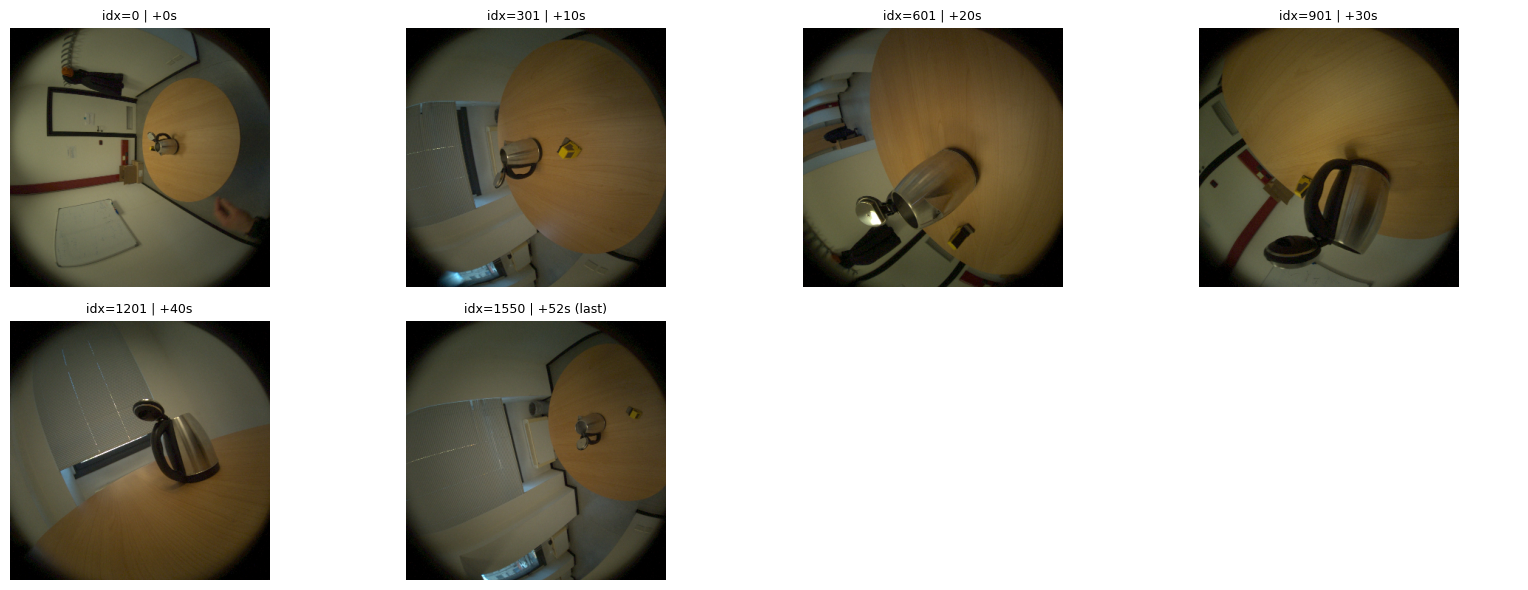

In [4]:
# as a sanity check we will create a grid with a frame every 10s

provider = create_provider(VRS_PATH)

rgb_label, rgb_stream_id, rgb_sample_count = resolve_rgb_stream(
    provider, rgb_stream_id_str="214-1"
)
rgb_timestamps_ns = get_rgb_timestamps_ns(provider, rgb_stream_id, rgb_sample_count)

print("RGB stream label:", rgb_label)
print("RGB stream id:", rgb_stream_id)
print("RGB sample count:", rgb_sample_count)

base_ts_ns = int(rgb_timestamps_ns[0])
last_ts_ns = int(rgb_timestamps_ns[-1])
duration_s = int((last_ts_ns - base_ts_ns) // 1_000_000_000)

step_s = 10
target_offsets_s = list(range(0, duration_s + 1, step_s))

# Get closest sample indices for target offsets
sample_indices = []
for off_s in target_offsets_s:
    target_ts_ns = base_ts_ns + off_s * 1_000_000_000
    idx = int(np.searchsorted(rgb_timestamps_ns, target_ts_ns, side="left"))
    if idx >= rgb_sample_count:
        idx = rgb_sample_count - 1
    sample_indices.append(idx)

# Force the last frame if it is not already included
if sample_indices[-1] != (rgb_sample_count - 1):
    sample_indices[-1] = rgb_sample_count - 1

# Remove duplicates while preserving order
seen = set()
sample_indices = [i for i in sample_indices if not (i in seen or seen.add(i))]

# Grid settings
downsample = 4  # 1=no resize, 2=1/2, 4=1/4
ncols = 4
nrows = (len(sample_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

# Display selected frames
for k in range(nrows * ncols):
    r, c = divmod(k, ncols)
    ax = axes[r, c]
    ax.axis("off")

    if k >= len(sample_indices):
        continue

    idx = sample_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = int(round((int(rgb_timestamps_ns[idx]) - base_ts_ns) / 1e9))
    is_last = (idx == rgb_sample_count - 1)

    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s}s{' (last)' if is_last else ''}", fontsize=9)

plt.tight_layout()
plt.show()

## 4.2 Prompt Initialization Frames

SAM-based segmentation relies on prompts to guide the model in identifying the target objects.
In this section, we select a small set of clean RGB frames to initialize segmentation prompts.
We use evenly spaced candidates and then define a final list of initialization indices.

In [5]:
# Select evenly spaced candidate frames for prompt initialization

# Number of candidate frames to inspect
n_candidates = 8 # arbitrary choice

# Avoid first and last frame for initialization
start_idx = max(0, int(0.05 * rgb_sample_count))
end_idx = min(rgb_sample_count - 1, int(0.95 * rgb_sample_count))

candidate_indices = np.linspace(start_idx, end_idx, n_candidates, dtype=int).tolist()
candidate_indices = list(dict.fromkeys(candidate_indices))  # keep unique, preserve order

print("Candidate indices:", candidate_indices)

Candidate indices: [77, 276, 475, 675, 874, 1074, 1273, 1473]


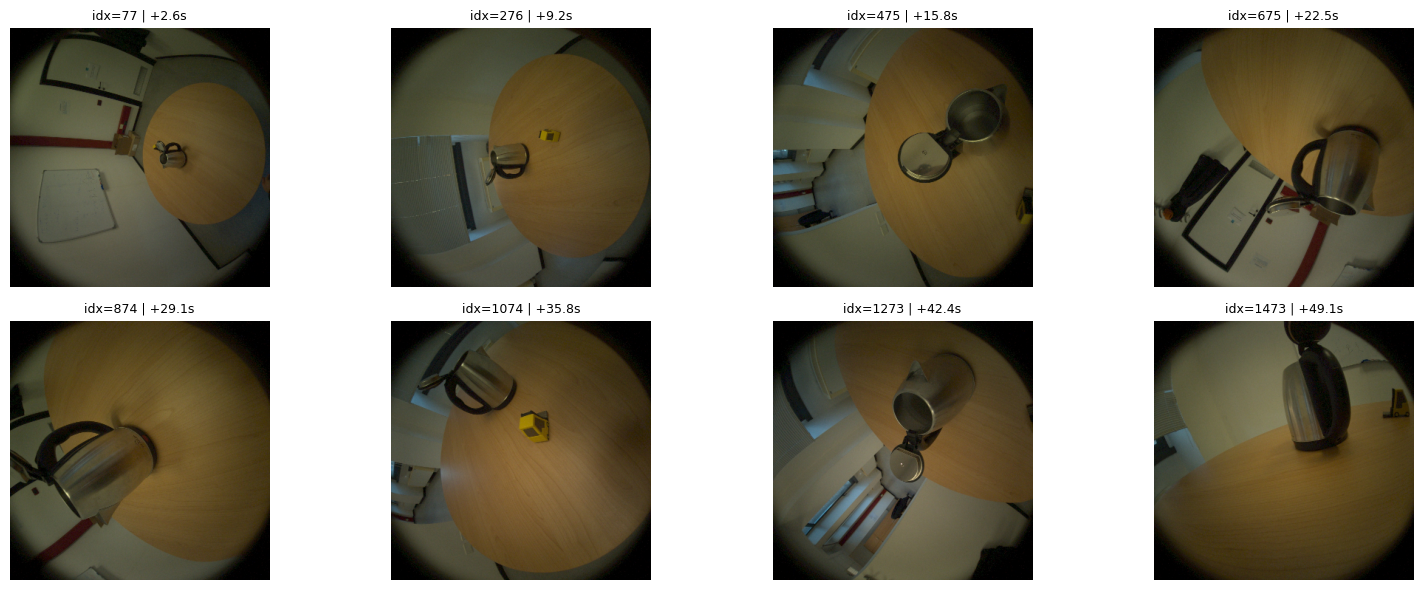

In [6]:
# Visualize candidate frames

downsample = 4
ncols = 4
nrows = (len(candidate_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for k in range(nrows * ncols):
    ax = axes.flat[k]
    ax.axis("off")
    if k >= len(candidate_indices):
        continue

    idx = candidate_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = (int(rgb_timestamps_ns[idx]) - int(rgb_timestamps_ns[0])) / 1e9
    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s:.1f}s", fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# Manual prompt initialization frames selected after visual inspection
PROMPT_INIT_INDICES = [201, 373, 911, 1131]
PROMPT_FRAME_IDX = PROMPT_INIT_INDICES[0] # frame 200 is the best

print("Selected PROMPT_INIT_INDICES:", PROMPT_INIT_INDICES)
print("PROMPT_FRAME_IDX:", PROMPT_FRAME_IDX)

Selected PROMPT_INIT_INDICES: [200, 373, 911, 1131]
PROMPT_FRAME_IDX: 200


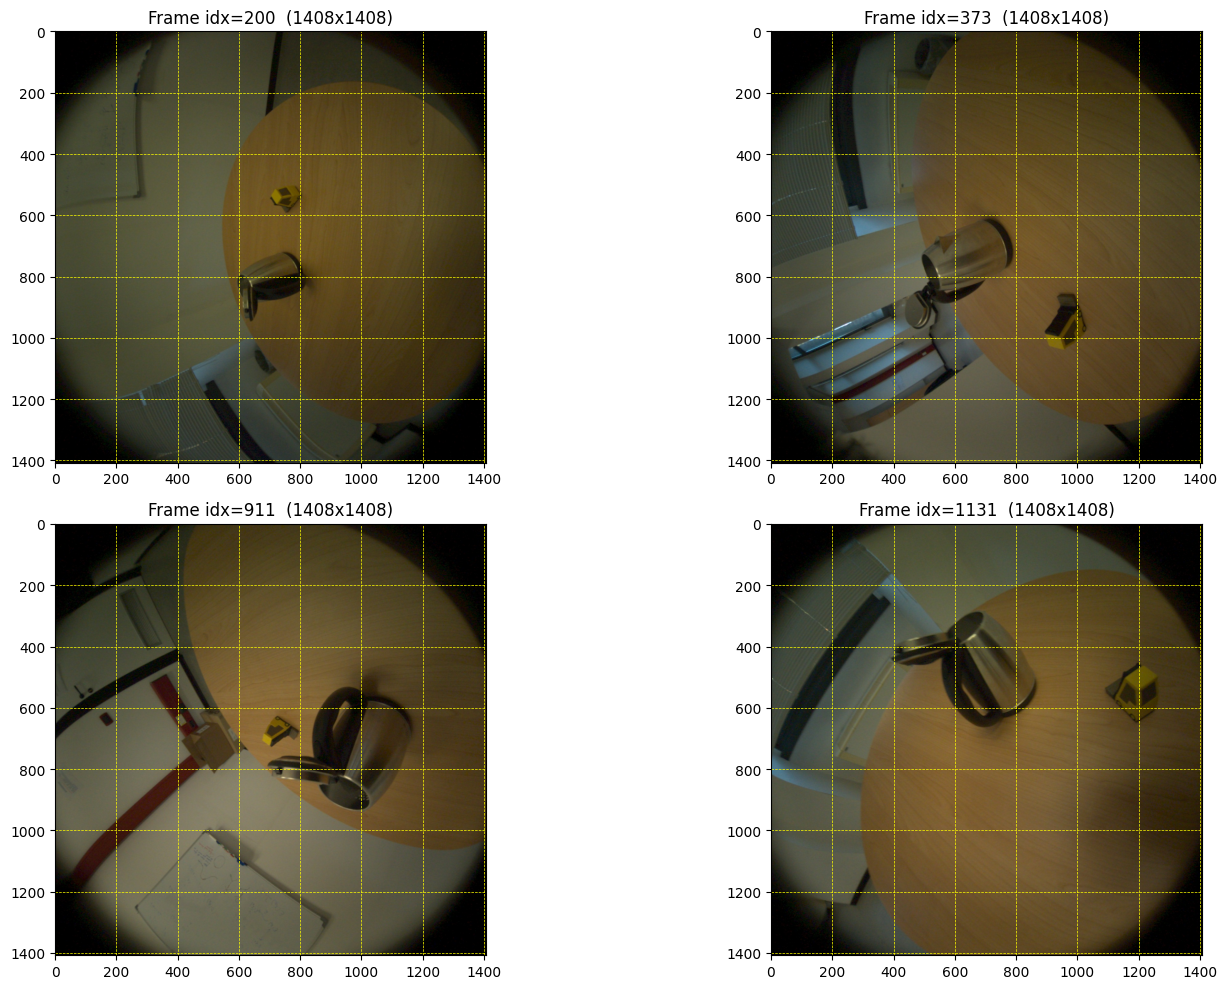

In [8]:
# Visualize the 4 selected prompt frames
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, idx in zip(axes, PROMPT_INIT_INDICES):
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    h, w = frame_rgb.shape[:2]
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame idx={idx}  ({w}x{h})")
    ax.axis("on")
    ax.set_xticks(np.arange(0, w + 1, 200))
    ax.set_yticks(np.arange(0, h + 1, 200))
    ax.grid(color="yellow", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

### Candidate Frame Selection Criteria

Candidate frames are **not** selected randomly.

The selection follows a deterministic rule:

1. Define a central window of the RGB stream:
   - `start_idx = 5%` of the total RGB frame count
   - `end_idx = 95%` of the total RGB frame count  
   This avoids very early and very late frames, which are often less stable for prompt initialization.

2. Select `n_candidates` **evenly spaced** indices between `start_idx` and `end_idx` using:
   - `np.linspace(start_idx, end_idx, n_candidates, dtype=int)`

3. Remove potential duplicates while preserving order:
   - useful when the sequence is short or when `n_candidates` is high.

As a result, for the same video and parameters (`n_candidates`, 5%-95% range), the selected candidate frames are always the same.

## 4.3 SAM2 Baseline Segmentation

In this section we will use the SAM2 model to perform segmentation on the RGB frames using box prompts for the forklift and kettle.

The workflow is:

1. Export the RGB video frames to a folder that SAM2 can read.
2. Load the SAM2 video predictor.
3. Define object prompts for the target classes:
   - forklift
   - kettle
4. Initialize the masks on one clean frame.
5. Propagate the masks across the full video.
6. Save masks and metadata for later diagnostics and quantitative analysis.

For the baseline, we use **box prompts** because they are stable, simple to inspect, and appropriate for the first segmentation pass.

In [9]:
from PIL import Image
import json
from collections import defaultdict

# SAM2 uses GPU when available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [10]:
# Output folders
SAM2_ROOT = Path(OUT_ROOT) / "sam2"
SAM2_FRAMES_DIR = SAM2_ROOT / "frames"
SAM2_MASKS_DIR = SAM2_ROOT / "masks"
SAM2_VIS_DIR = SAM2_ROOT / "visualizations"

SAM2_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
SAM2_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM2_VIS_DIR.mkdir(parents=True, exist_ok=True)


In [11]:
# 4.3.1 Function to export RGB frames as images for SAM2 processing
def export_rgb_frames(
    provider,
    stream_id,
    sample_count: int,
    out_dir: Path,
    ext: str = "jpg",
    jpg_quality: int = 95,
    force_rebuild: bool = False,
):
    """
    Export RGB frames as jpg images:
    000000.jpg, 000001.jpg, etc...
    If cache is complete and force_rebuild=False, skip export.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    # Check cache completeness
    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(sample_count)]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"Frame cache already complete. Skipping export: {out_dir}")
        return

    # If force_rebuild, clear existing files
    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    # Export frames
    for i in range(sample_count):
        out_path = out_dir / f"{i:06d}.jpg"
        if out_path.exists() and not force_rebuild:
            continue

        frame_rgb = get_rgb_frame_by_index(provider, stream_id, i)
        img = Image.fromarray(frame_rgb)
        img.save(out_path, quality=jpg_quality, subsampling=0, optimize=True)

    print(f"Export completed: {out_dir} ({sample_count} frames, .jpg)")


export_rgb_frames(
    provider=provider,
    stream_id=rgb_stream_id,
    sample_count=rgb_sample_count,
    out_dir=SAM2_FRAMES_DIR,
    ext="jpg",
    jpg_quality=95,
    force_rebuild=False,
)

Frame cache already complete. Skipping export: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames


In [12]:
from pathlib import Path

# Validate SAM2 config and checkpoint paths
SAM2_CONFIG_FILE = Path("..") / "third_party" / "sam2" / "sam2" / "configs" / "sam2" / "sam2_hiera_s.yaml"
SAM2_CHECKPOINT = Path("..") / "checkpoints" / "sam2_hiera_small.pt"

if not SAM2_CONFIG_FILE.exists():
    raise FileNotFoundError(f"SAM2 config non trovato: {SAM2_CONFIG_FILE.resolve()}")
if not SAM2_CHECKPOINT.exists():
    raise FileNotFoundError(f"SAM2 checkpoint non trovato: {SAM2_CHECKPOINT.resolve()}")

print("SAM2_CONFIG_FILE:", SAM2_CONFIG_FILE.resolve())
print("SAM2_CHECKPOINT:", SAM2_CHECKPOINT.resolve())

SAM2_CONFIG_FILE: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\configs\sam2\sam2_hiera_s.yaml
SAM2_CHECKPOINT: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\checkpoints\sam2_hiera_small.pt


In [13]:
from sam2.build_sam import build_sam2_video_predictor

#! Hydra wants a config-name, not an absolute path
SAM2_CONFIG_NAME = "configs/sam2/sam2_hiera_s.yaml"

# 4.3.2 Initialize SAM2 predictor
sam2_predictor = build_sam2_video_predictor(
    config_file=SAM2_CONFIG_NAME,
    ckpt_path=str(SAM2_CHECKPOINT),
    device=DEVICE,
)

print("Loaded SAM2 predictor.")

Loaded SAM2 predictor.


In [14]:
# 4.3 Define box prompts for the target objects on one clean frame

# NOTE: adjust these coordinates after visual inspection if needed
PROMPT_FRAME_IDX = PROMPT_INIT_INDICES[0]

# Example boxes: [x0, y0, x1, y1]
BOX_PROMPTS = {
    "forklift": [675, 475, 825, 600],
    "kettle": [575, 700, 825, 975],
}

print("PROMPT_FRAME_IDX:", PROMPT_FRAME_IDX)
print("BOX_PROMPTS:", BOX_PROMPTS)

PROMPT_FRAME_IDX: 200
BOX_PROMPTS: {'forklift': [675, 475, 825, 600], 'kettle': [575, 700, 825, 975]}


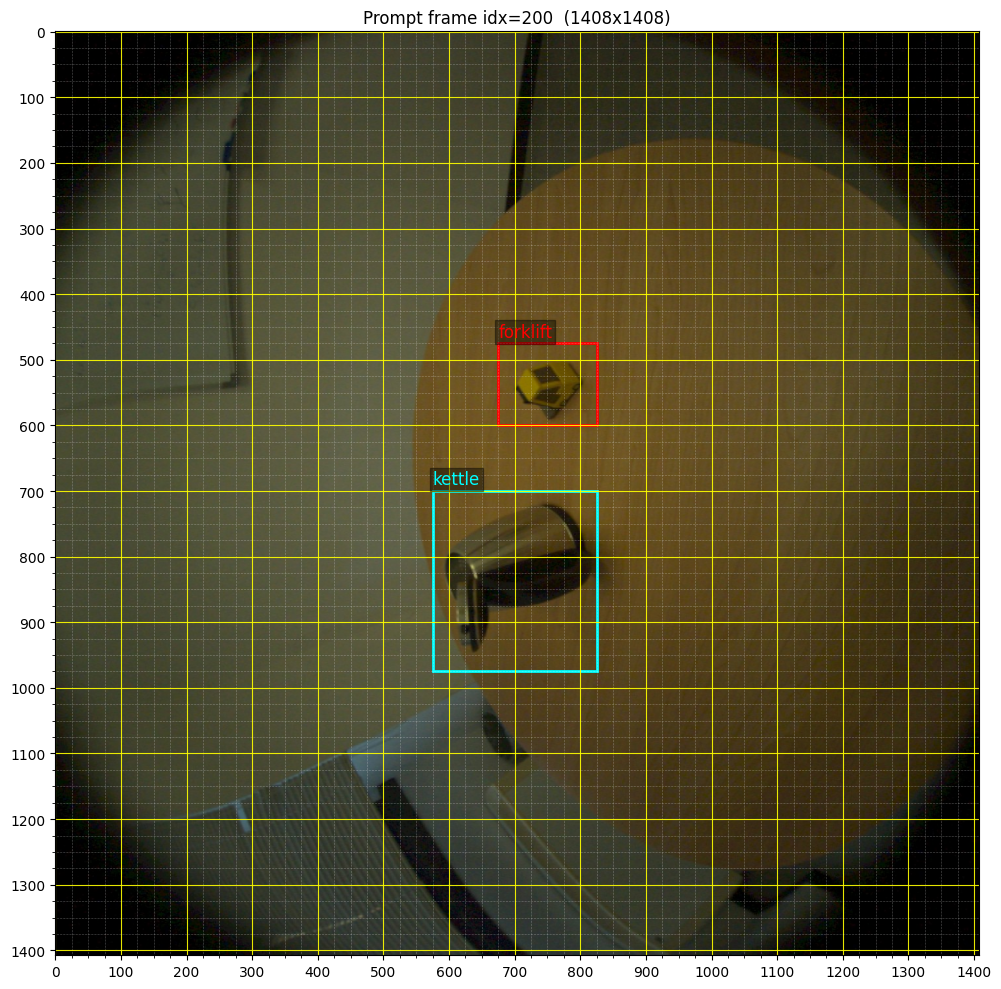

In [15]:
import matplotlib.patches as patches
import numpy as np

# 4.3.4 Load the prompt frame
prompt_frame = get_rgb_frame_by_index(provider, rgb_stream_id, PROMPT_FRAME_IDX)
h, w = prompt_frame.shape[:2]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(prompt_frame)
ax.set_title(f"Prompt frame idx={PROMPT_FRAME_IDX}  ({w}x{h})")
ax.axis("on")

# Detailed pixel grid
major_step = 100
minor_step = 25

ax.set_xticks(np.arange(0, w + 1, major_step))
ax.set_yticks(np.arange(0, h + 1, major_step))
ax.set_xticks(np.arange(0, w + 1, minor_step), minor=True)
ax.set_yticks(np.arange(0, h + 1, minor_step), minor=True)

ax.grid(which="major", color="yellow", linestyle="-", linewidth=0.8, alpha=0.9)
ax.grid(which="minor", color="white", linestyle=":", linewidth=0.4, alpha=0.6)

# Draw boxes
colors = {
    "forklift": "red",
    "kettle": "cyan",
}

for name, box in BOX_PROMPTS.items():
    x0, y0, x1, y1 = box
    rect = patches.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=2,
        edgecolor=colors.get(name, "yellow"),
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.text(
        x0,
        max(0, y0 - 10),
        name,
        color=colors.get(name, "yellow"),
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.4, pad=2),
    )

plt.tight_layout()
plt.show()

### 4.3.5 Smart gaze-driven crop with temporal smoothing

To balance VRAM efficiency and temporal stability for SAM2, we use a **dynamically centered crop with smoothing**. Specifically:

1. Extract eye-gaze coordinates for each RGB frame.
2. Apply rolling average to smooth micro-saccades and jitter.
3. Center a fixed `1024x1024` crop on the smoothed gaze point.
4. Clamp boundaries to frame limits (1408x1408), maintaining final size.
5. Export the cropped RGB sequence and remap the box prompts.


This approach keeps the target objects within the crop while reducing VRAM usage and minimizing mask jitter caused by small gaze fluctuations. The rolling average window size can be tuned to balance responsiveness and stability.



In [16]:
import numpy as np
import pandas as pd
from pathlib import Path

# Function to prepare gaze samples from the DataFrame
def prepare_gaze_samples(df: pd.DataFrame):
    # Validate required columns
    required_cols = [
        "tracking_timestamp_us",
        "left_yaw_rads_cpf",
        "right_yaw_rads_cpf",
        "pitch_rads_cpf",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise RuntimeError(f"Missing required gaze columns: {missing}")

    # Convert to numpy arrays, coerce errors to NaN, and filter valid samples
    gt = pd.to_numeric(df["tracking_timestamp_us"], errors="coerce").to_numpy(dtype=np.float64) * 1_000.0
    left_yaw = pd.to_numeric(df["left_yaw_rads_cpf"], errors="coerce").to_numpy(dtype=np.float64)
    right_yaw = pd.to_numeric(df["right_yaw_rads_cpf"], errors="coerce").to_numpy(dtype=np.float64)
    pitch = pd.to_numeric(df["pitch_rads_cpf"], errors="coerce").to_numpy(dtype=np.float64)

    # Filter out samples with any non-finite values
    valid = np.isfinite(gt) & np.isfinite(left_yaw) & np.isfinite(right_yaw) & np.isfinite(pitch)
    gt = gt[valid]
    yaw = 0.5 * (left_yaw[valid] + right_yaw[valid])
    pitch = pitch[valid]

    if gt.size < 2:
        raise RuntimeError("Not enough valid gaze samples.")

    order = np.argsort(gt)
    return gt[order], yaw[order], pitch[order]

In [17]:
# Load and prepare eye-gaze samples from the CSV file
GAZE_CANDIDATE = Path("..") / "data" / "raw" / "kettle_and_forklift" / "mps_kettle_and_forklift_recording_vrs" / "eye_gaze" / "general_eye_gaze.csv"

if not GAZE_CANDIDATE.exists():
    raise FileNotFoundError(f"Eye-gaze CSV not found: {GAZE_CANDIDATE}")

gaze_df = pd.read_csv(GAZE_CANDIDATE)
gt, yaw, pitch = prepare_gaze_samples(gaze_df)

print("Gaze samples:", len(gt))

Gaze samples: 1551


### Timestamp alignment and approximate gaze mapping

The eye-gaze samples are not synchronized one-to-one with RGB frames, so we align them to the RGB timestamps using linear interpolation.

Then we convert yaw and pitch into an approximate image position using a simple rule:
- average the two yaw values
- apply light smoothing
- convert the angles into pixel coordinates with an heuristic mapping

This is intentionally simple and only meant to define a reasonable crop center.

In [18]:
# Assumes rgb_timestamps_ns, rgb_sample_count, provider, rgb_stream_id already exist

sample_frame = get_rgb_frame_by_index(provider, rgb_stream_id, 0)
H, W = sample_frame.shape[:2]

rgb_ts = rgb_timestamps_ns.astype(np.float64)

yaw_i = np.interp(rgb_ts, gt.astype(np.float64), yaw)
pitch_i = np.interp(rgb_ts, gt.astype(np.float64), pitch)

# very simple heuristic mapping
yaw_i = np.convolve(yaw_i, np.ones(11) / 11, mode="same")
pitch_i = np.convolve(pitch_i, np.ones(11) / 11, mode="same")

GAIN_X = W * 0.25
GAIN_Y = H * 0.25

# Map yaw and pitch to pixel coordinates, centered at (W/2, H/2)
gaze_x = np.clip(W / 2 + np.tan(yaw_i) * GAIN_X, 0, W - 1)
gaze_y = np.clip(H / 2 - np.tan(pitch_i) * GAIN_Y, 0, H - 1)

# Print example gaze point
print("Example gaze point:", gaze_x[0], gaze_y[0])

Example gaze point: 686.9079369684022 760.6784414953696


In [19]:
from PIL import Image
# Define crop size for SAM2 input
CROP_W = 1024
CROP_H = 1024
force_rebuild = False # Set to True to force re-cropping even if cached crops exist

# Function to compute crop box coordinates from center point, ensuring it stays within image bounds
def crop_box_from_center(cx, cy, w, h, crop_w, crop_h):
    x0 = int(np.clip(cx - crop_w // 2, 0, max(0, w - crop_w)))
    y0 = int(np.clip(cy - crop_h // 2, 0, max(0, h - crop_h)))
    return x0, y0, x0 + crop_w, y0 + crop_h

crop_boxes = np.array(
    [crop_box_from_center(cx, cy, W, H, CROP_W, CROP_H) for cx, cy in zip(gaze_x, gaze_y)],
    dtype=int,
)

SAM2_FRAMES_DIR_CROP = SAM2_ROOT / "frames_crop_1024x1024"
SAM2_FRAMES_DIR_CROP.mkdir(parents=True, exist_ok=True)

expected_files = [SAM2_FRAMES_DIR_CROP / f"{i:06d}.jpg" for i in range(rgb_sample_count)]
cache_complete = all(p.exists() for p in expected_files)

if cache_complete and not force_rebuild:
    print(f"Cropped frames already exist. Skipping: {SAM2_FRAMES_DIR_CROP}")
else:
    if force_rebuild:
        for p in SAM2_FRAMES_DIR_CROP.glob("*.jpg"):
            p.unlink()

    for i in range(rgb_sample_count):
        out_path = SAM2_FRAMES_DIR_CROP / f"{i:06d}.jpg"
        if out_path.exists() and not force_rebuild:
            continue

        frame = get_rgb_frame_by_index(provider, rgb_stream_id, i)
        x0, y0, x1, y1 = crop_boxes[i]
        crop = frame[y0:y1, x0:x1]
        Image.fromarray(crop).save(out_path, quality=95, subsampling=0, optimize=True)


Cropped frames already exist. Skipping: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames_crop_1024x1024


### Box remapping on the cropped frame

The original box prompts were defined on the full-resolution RGB frame.  
Since SAM2 will now operate on the cropped images, the box coordinates must be shifted into the crop coordinate system.

This remapping is done using the crop top-left corner as an offset.

In [20]:
# Remap box prompts to crop coordinates for the selected prompt frame
def shift_box_to_crop(box, crop_box):
    x0, y0, _, _ = crop_box
    bx0, by0, bx1, by1 = box
    return [bx0 - x0, by0 - y0, bx1 - x0, by1 - y0]

crop_box = crop_boxes[PROMPT_FRAME_IDX]
BOX_PROMPTS_CROP = {
    name: shift_box_to_crop(box, crop_box)
    for name, box in BOX_PROMPTS.items()
}

print("Crop box:", crop_box)
print("BOX_PROMPTS_CROP:", BOX_PROMPTS_CROP)

Crop box: [ 273  295 1297 1319]
BOX_PROMPTS_CROP: {'forklift': [np.int64(402), np.int64(180), np.int64(552), np.int64(305)], 'kettle': [np.int64(302), np.int64(405), np.int64(552), np.int64(680)]}


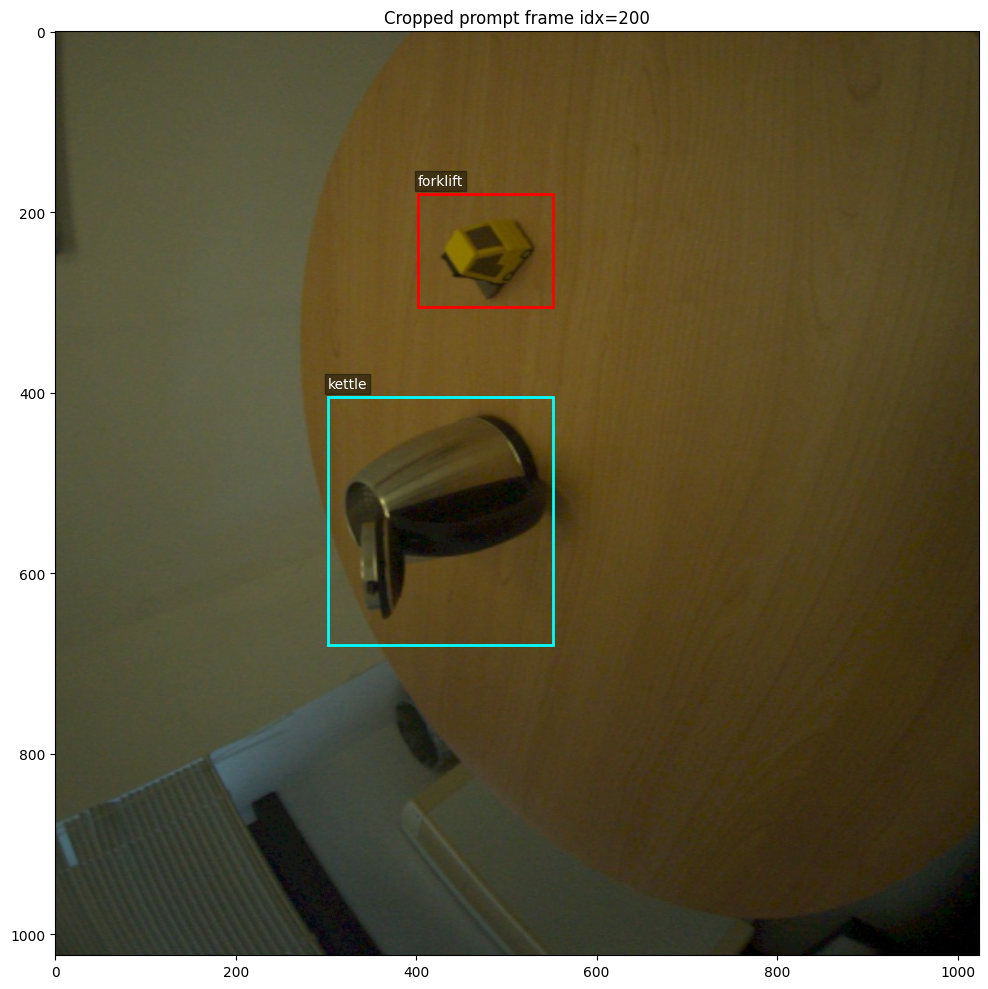

In [21]:
import matplotlib.patches as patches

# Visualize the cropped prompt frame with remapped box prompts
crop_frame = get_rgb_frame_by_index(provider, rgb_stream_id, PROMPT_FRAME_IDX)
x0, y0, x1, y1 = crop_boxes[PROMPT_FRAME_IDX]
crop_frame = crop_frame[y0:y1, x0:x1]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(crop_frame)
ax.set_title(f"Cropped prompt frame idx={PROMPT_FRAME_IDX}")
ax.axis("on")

# Detailed pixel grid
for name, box in BOX_PROMPTS_CROP.items():
    bx0, by0, bx1, by1 = box
    rect = patches.Rectangle(
        (bx0, by0),
        bx1 - bx0,
        by1 - by0,
        linewidth=2,
        edgecolor="red" if name == "forklift" else "cyan",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.text(bx0, max(0, by0 - 10), name, color="white",
            bbox=dict(facecolor="black", alpha=0.4, pad=2))

plt.tight_layout()
plt.show()

### 4.3.6 SAM2 inference

In this step we run SAM2 Small on the cropped RGB sequence.
The propagation is executed on GPU only, using the remapped box prompts on the selected prompt frame.
Outputs are saved as label masks, per-frame metadata, and visual overlays.

In [22]:
from PIL import Image
import json

# Enforce GPU-only run for this experiment
if DEVICE != "cuda":
    raise RuntimeError("CUDA is required for SAM2 small inference in this run.")

SAM2_RUN_NAME = "small_crop_1024x1024"
SAM2_RUN_DIR = SAM2_ROOT / SAM2_RUN_NAME
SAM2_RUN_MASKS_DIR = SAM2_RUN_DIR / "masks"
SAM2_RUN_VIS_DIR = SAM2_RUN_DIR / "visualizations"
SAM2_RUN_META_PATH = SAM2_RUN_DIR / "metadata.json"

SAM2_RUN_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM2_RUN_VIS_DIR.mkdir(parents=True, exist_ok=True)

# Object IDs used by SAM2
OBJECT_IDS = {
    "forklift": 1,
    "kettle": 2,
}

def mask_logits_to_binary(mask_logits):
    """Convert SAM2 mask logits to a uint8 binary mask."""
    return (mask_logits > 0).detach().cpu().numpy().astype("uint8")

def build_label_mask(frame_shape, obj_masks):
    """Merge per-object binary masks into a single label map."""
    h, w = frame_shape[:2]
    label_mask = np.zeros((h, w), dtype=np.uint8)
    for obj_name, binary_mask in obj_masks.items():
        label_mask[binary_mask > 0] = OBJECT_IDS[obj_name]
    return label_mask

def save_label_mask_png(label_mask, out_path):
    """Save a label mask as PNG."""
    Image.fromarray(label_mask).save(out_path)

def save_overlay(frame_rgb, label_mask, out_path):
    """Save a simple overlay for quick inspection."""
    overlay = frame_rgb.copy()
    colors = {
        1: np.array([255, 0, 0], dtype=np.uint8),    # forklift
        2: np.array([0, 255, 255], dtype=np.uint8),  # kettle
    }
    alpha = 0.45

    # Blend colors for each object ID
    for obj_id, color in colors.items():
        m = label_mask == obj_id
        overlay[m] = (1 - alpha) * overlay[m] + alpha * color

    Image.fromarray(overlay.astype(np.uint8)).save(out_path)

In [59]:
# clean up GPU memory before starting inference
import gc
import torch

# Clear Python references first
gc.collect()

if torch.cuda.is_available():
    # Wait for pending CUDA ops to finish
    torch.cuda.synchronize()

    # Release cached GPU memory held by PyTorch
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    # Optional: reset peak stats for cleaner monitoring
    torch.cuda.reset_peak_memory_stats()

    allocated_gb = torch.cuda.memory_allocated() / (1024**3)
    reserved_gb = torch.cuda.memory_reserved() / (1024**3)
    print(f"GPU memory after cleanup -> allocated: {allocated_gb:.3f} GB, reserved: {reserved_gb:.3f} GB")
else:
    print("CUDA not available.")

GPU memory after cleanup -> allocated: 0.333 GB, reserved: 0.553 GB


In [60]:
# Ensure no lingering references to SAM2 state or predictor that could hold GPU memory
for v in ["inference_state"]:
    if v in globals():
        del globals()[v]
import gc, torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
# Run SAM2 small on 10fps frames (GPU only)
from PIL import Image

if DEVICE != "cuda":
    raise RuntimeError("CUDA is required for this run.")

SAM2_FRAMES_DIR_10FPS = SAM2_ROOT / "frames_10fps"
if not SAM2_FRAMES_DIR_10FPS.exists():
    raise FileNotFoundError(f"Missing 10fps frames folder: {SAM2_FRAMES_DIR_10FPS}")

frame_files_10fps = sorted(SAM2_FRAMES_DIR_10FPS.glob("*.jpg"))
if len(frame_files_10fps) == 0:
    raise RuntimeError(f"No JPG frames found in: {SAM2_FRAMES_DIR_10FPS}")

SAM2_MASKS_DIR = SAM2_ROOT / "masks"
SAM2_VIS_DIR = SAM2_ROOT / "visualizations"

SAM2_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM2_VIS_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_PREVIOUS_OUTPUTS = False
if CLEAN_PREVIOUS_OUTPUTS:
    for p in SAM2_MASKS_DIR.glob("*.png"):
        p.unlink()
    for p in SAM2_VIS_DIR.glob("*.jpg"):
        p.unlink()

# Prompt frame index must be valid inside the 10fps sequence
prompt_frame_idx_10fps = int(min(PROMPT_FRAME_IDX, len(frame_files_10fps) - 1))

# Cleanup before state initialization
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Explicitly disable CPU offloading
inference_state = sam2_predictor.init_state(
    video_path=str(SAM2_FRAMES_DIR_10FPS),
    offload_video_to_cpu=False,
    offload_state_to_cpu=False,
)
sam2_predictor.reset_state(inference_state)

print("Initialized SAM2 state on:", SAM2_FRAMES_DIR_10FPS)
print("Frames available:", len(frame_files_10fps))
print("Prompt frame idx used:", prompt_frame_idx_10fps)

# Add box prompts on the selected frame
for obj_name, box in BOX_PROMPTS.items():
    obj_id = OBJECT_IDS[obj_name]
    _, out_obj_ids, out_mask_logits = sam2_predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=prompt_frame_idx_10fps,
        obj_id=int(obj_id),
        box=np.array(box, dtype=np.float32),
    )
    print(f"Added prompt: {obj_name} -> obj_id={obj_id}, box={box}")


# Propagate masks both before and after the prompt frame
all_results = {}

def process_output(out_frame_idx, out_obj_ids, out_mask_logits):
    out_frame_idx = int(out_frame_idx)

    frame_path = SAM2_FRAMES_DIR_10FPS / f"{out_frame_idx:06d}.jpg"
    if frame_path.exists():
        frame_rgb = np.array(Image.open(frame_path).convert("RGB"))
    else:
        # Fallback in case file naming is not contiguous
        frame_rgb = np.array(Image.open(frame_files_10fps[out_frame_idx]).convert("RGB"))

    obj_masks = {}
    for i, obj_id in enumerate(out_obj_ids):
        obj_id = int(obj_id)
        if obj_id == OBJECT_IDS["forklift"]:
            obj_name = "forklift"
        elif obj_id == OBJECT_IDS["kettle"]:
            obj_name = "kettle"
        else:
            continue

        obj_masks[obj_name] = mask_logits_to_binary(out_mask_logits[i, 0])

    label_mask = build_label_mask(frame_rgb.shape, obj_masks)

    mask_path = SAM2_MASKS_DIR / f"{out_frame_idx:06d}.png"
    vis_path = SAM2_VIS_DIR / f"{out_frame_idx:06d}.jpg"

    save_label_mask_png(label_mask, mask_path)
    save_overlay(frame_rgb, label_mask, vis_path)

    all_results[out_frame_idx] = {
        "frame_path": str(frame_path),
        "mask_path": str(mask_path),
        "vis_path": str(vis_path),
        "objects": list(obj_masks.keys()),
    }

# Backward pass: frames before the selected prompt
backward_count = 0
for out_frame_idx, out_obj_ids, out_mask_logits in sam2_predictor.propagate_in_video(
    inference_state, reverse=True
):
    idx = int(out_frame_idx)
    if idx in all_results:
        continue
    process_output(out_frame_idx, out_obj_ids, out_mask_logits)
    backward_count += 1

# Forward pass: frames after the selected prompt
forward_count = 0
for out_frame_idx, out_obj_ids, out_mask_logits in sam2_predictor.propagate_in_video(inference_state):
    idx = int(out_frame_idx)
    if idx in all_results:
        continue
    process_output(out_frame_idx, out_obj_ids, out_mask_logits)
    forward_count += 1

print("Backward frames processed:", backward_count)
print("Forward frames processed:", forward_count)
print("Total unique frames processed:", len(all_results))
print("Masks folder:", SAM2_MASKS_DIR)
print("Visualization folder:", SAM2_VIS_DIR)

frame loading (JPEG): 100%|██████████| 517/517 [00:35<00:00, 14.42it/s]


Initialized SAM2 state on: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames_10fps
Frames available: 517
Prompt frame idx used: 201


C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Added prompt: forklift -> obj_id=1, box=[675, 475, 825, 600]
Added prompt: kettle -> obj_id=2, box=[575, 700, 825, 975]


propagate in video: 100%|██████████| 316/316 [1:35:30<00:00, 18.13s/it]

Backward frames processed: 202
Forward frames processed: 315
Total unique frames processed: 517
Masks folder: ..\data\outputs\segmentation\kettle_and_forklift\sam2\masks
Visualization folder: ..\data\outputs\segmentation\kettle_and_forklift\sam2\visualizations
